In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/anthonytherrien/dog-vs-cat/animals/dog/00985-127787239.png
/kaggle/input/datasets/anthonytherrien/dog-vs-cat/animals/dog/00667-3846168829.png
/kaggle/input/datasets/anthonytherrien/dog-vs-cat/animals/dog/00891-3846169053.png
/kaggle/input/datasets/anthonytherrien/dog-vs-cat/animals/dog/00528-3846168690.png
/kaggle/input/datasets/anthonytherrien/dog-vs-cat/animals/dog/00689-3846168851.png
/kaggle/input/datasets/anthonytherrien/dog-vs-cat/animals/dog/00593-3846168755.png
/kaggle/input/datasets/anthonytherrien/dog-vs-cat/animals/dog/00894-3846169056.png
/kaggle/input/datasets/anthonytherrien/dog-vs-cat/animals/dog/00622-3846168784.png
/kaggle/input/datasets/anthonytherrien/dog-vs-cat/animals/dog/00907-3846169069.png
/kaggle/input/datasets/anthonytherrien/dog-vs-cat/animals/dog/00983-127787237.png
/kaggle/input/datasets/anthonytherrien/dog-vs-cat/animals/dog/00817-3846168979.png
/kaggle/input/datasets/anthonytherrien/dog-vs-cat/animals/dog/00576-3846168738.png
/kaggl

In [2]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense,Conv2D,MaxPooling2D ,Flatten, Rescaling, Dropout,BatchNormalization
import matplotlib.pyplot as plt
import os
import warnings
warnings.filterwarnings("ignore")

2026-05-25 04:30:30.875743: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1779683431.124484      16 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1779683431.192297      16 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1779683431.749815      16 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1779683431.749871      16 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1779683431.749875      16 computation_placer.cc:177] computation placer alr

In [3]:
original_dataset = "/kaggle/input/dog-vs-cat/animals"

In [4]:
train_ds = keras.utils.image_dataset_from_directory(
    "/kaggle/input/datasets/anthonytherrien/dog-vs-cat/animals",
    validation_split=0.2,
    labels='inferred',
    label_mode='int',
    subset= "training",
    seed= 42,
    image_size= (256,256),
    batch_size=10
)

Found 1000 files belonging to 2 classes.
Using 800 files for training.


2026-05-25 04:31:01.751708: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


In [5]:
valid_ds = keras.utils.image_dataset_from_directory(
    "/kaggle/input/datasets/anthonytherrien/dog-vs-cat/animals",
    validation_split=0.2,
    labels='inferred',
    label_mode='int',
    subset= "validation",
    seed= 42,
    image_size= (256,256),
    batch_size=10
)

Found 1000 files belonging to 2 classes.
Using 200 files for validation.


In [6]:

cat_count = len(os.listdir('/kaggle/input/datasets/anthonytherrien/dog-vs-cat/animals/cat'))
dog_count = len(os.listdir('/kaggle/input/datasets/anthonytherrien/dog-vs-cat/animals/dog'))

print("Cats:", cat_count)
print("Dogs:", dog_count)

Cats: 500
Dogs: 500


In [7]:
# Normilize( 0 to 1 )

def process(image,label):
    image=tf.cast(image/255,tf.float32)
    return image,label

train_ds=train_ds.map(process)
valid_ds=valid_ds.map(process)

In [8]:
# from tensorflow.keras.layers import RandomFlip, RandomRotation

# data_augmentation = keras.Sequential([
#     RandomFlip("horizontal"),
#     RandomRotation(0.1),
# ])

In [9]:
model=Sequential()

model.add(Conv2D(32,kernel_size=(3,3),padding='same',activation="relu",input_shape=(256,256,3)))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2,2),padding='same',strides=2))

model.add(Conv2D(64,kernel_size=(3,3),padding='same',activation="relu"))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2,2),padding='same',strides=2))

model.add(Conv2D(128,kernel_size=(3,3),padding='same',activation="relu"))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2,2),padding='same',strides=2))

# model.add(data_augmentation)
model.add(Flatten())
model.add(Dense(128,activation='relu'))
model.add(Dropout(0.5))
model.add(Dense(64,activation='relu'))
model.add(Dense(1,activation='sigmoid'))

In [10]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 256, 256, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 256, 256, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 128, 128, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 128, 128, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 128, 128, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 64, 64, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 64, 64, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 64, 64, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 32, 32, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 131072)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │    16,777,344 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 16,879,809 (64.39 MB)

 Trainable params: 16,879,361 (64.39 MB)

 Non-trainable params: 448 (1.75 KB)

In [11]:
model.compile(optimizer='adam',loss='binary_crossentropy',metrics=['accuracy'])

In [12]:
history=model.fit(train_ds,epochs=10,validation_data=valid_ds)

Epoch 1/10
80/80 ━━━━━━━━━━━━━━━━━━━━ 126s 2s/step - accuracy: 0.6474 - loss: 7.2788 - val_accuracy: 0.4950 - val_loss: 4.7299
Epoch 2/10
80/80 ━━━━━━━━━━━━━━━━━━━━ 124s 2s/step - accuracy: 0.7143 - loss: 4.5168 - val_accuracy: 0.6200 - val_loss: 7.2287
Epoch 3/10
80/80 ━━━━━━━━━━━━━━━━━━━━ 122s 2s/step - accuracy: 0.7619 - loss: 3.0518 - val_accuracy: 0.5350 - val_loss: 13.0196
Epoch 4/10
80/80 ━━━━━━━━━━━━━━━━━━━━ 118s 1s/step - accuracy: 0.8165 - loss: 1.6137 - val_accuracy: 0.6250 - val_loss: 8.8444
Epoch 5/10
80/80 ━━━━━━━━━━━━━━━━━━━━ 118s 1s/step - accuracy: 0.8087 - loss: 1.0588 - val_accuracy: 0.8050 - val_loss: 2.8983
Epoch 6/10
80/80 ━━━━━━━━━━━━━━━━━━━━ 118s 1s/step - accuracy: 0.8299 - loss: 1.0166 - val_accuracy: 0.8650 - val_loss: 1.9864
Epoch 7/10
80/80 ━━━━━━━━━━━━━━━━━━━━ 118s 1s/step - accuracy: 0.8752 - loss: 0.4494 - val_accuracy: 0.7950 - val_loss: 2.0493
Epoch 8/10
80/80 ━━━━━━━━━━━━━━━━━━━━ 118s 1s/step - accuracy: 0.8578 - loss: 0.6508 - val_accuracy: 0.8150 - 

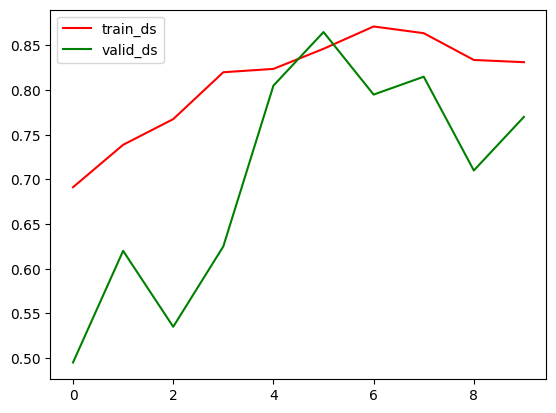

In [13]:
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'],color='red',label='train_ds')
plt.plot(history.history['val_accuracy'],color='green',label='valid_ds')
plt.legend()
plt.show()

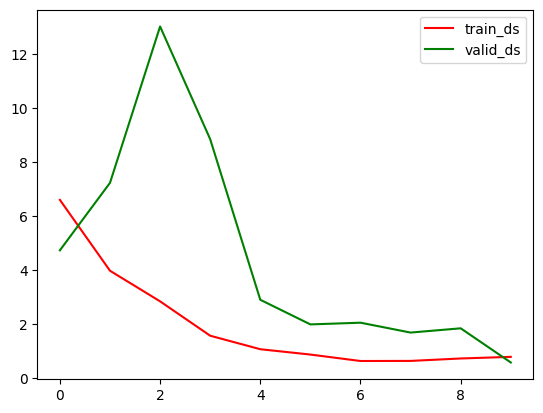

In [14]:
plt.plot(history.history['loss'],color='red',label='train_ds')
plt.plot(history.history['val_loss'],color='green',label='valid_ds')
plt.legend()
plt.show()

In [15]:
from sklearn.metrics import confusion_matrix, classification_report

y_true = []
y_pred = []

for images, labels in valid_ds:
    preds = model.predict(images)
    preds = (preds > 0.5).astype("int32")

    y_true.extend(labels.numpy())
    y_pred.extend(preds)

print(confusion_matrix(y_true, y_pred))
print(classification_report(y_true, y_pred))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 470ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 279ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 277ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 273ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 277ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 287ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 287ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 274ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 291ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 290ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 283ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 283ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 275ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 285ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 319ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 282ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 286ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 277ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 280ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 274ms/step
[[97  4]
 [42 57]]
              precision    recall  f1-score   support

           0       0.70      0.96      0.81       101
           1       0.93      0.58      0.71        99

    accuracy                         

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 471ms/step


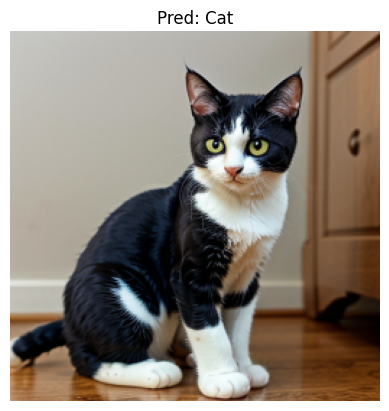

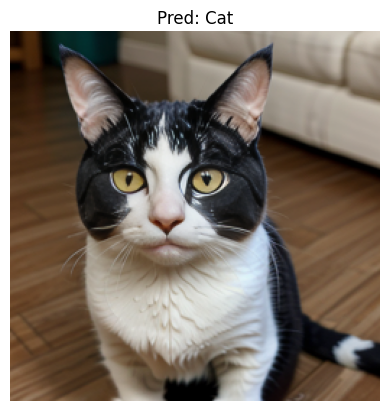

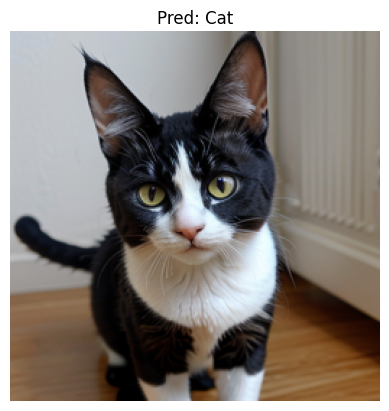

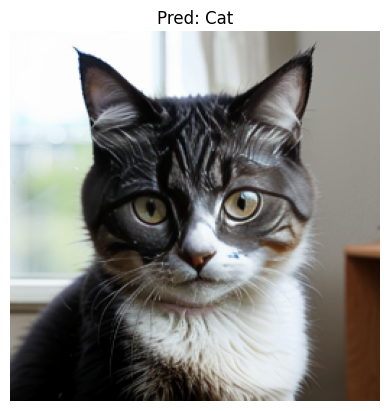

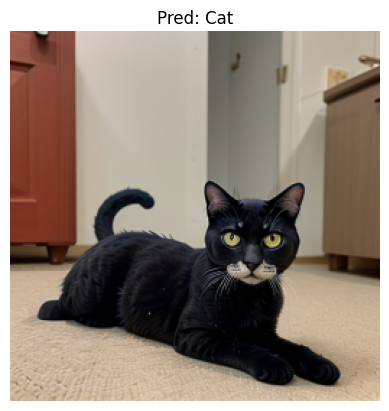

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 278ms/step


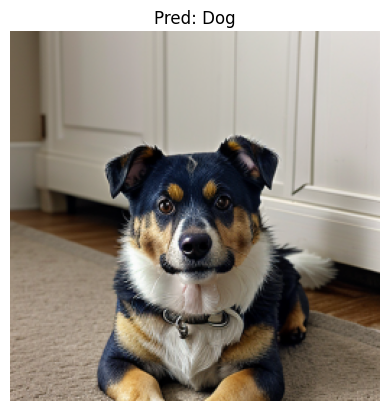

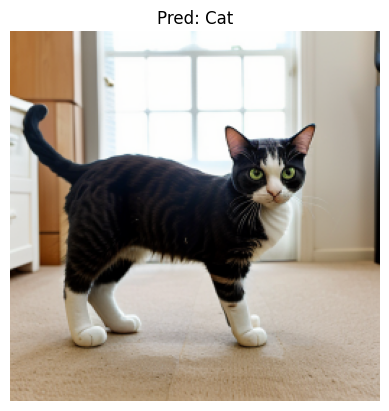

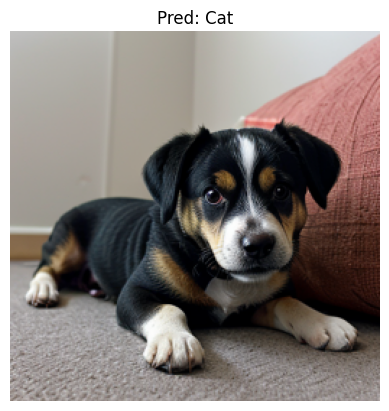

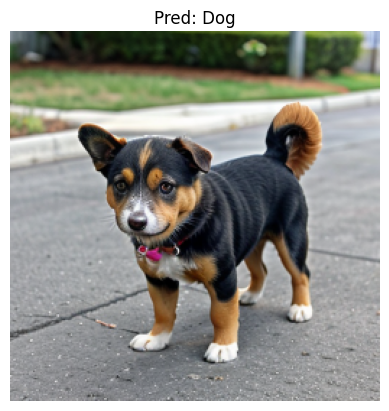

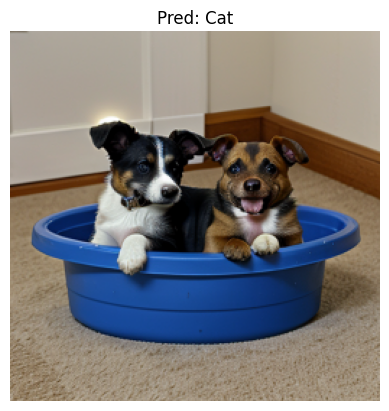

In [16]:
import matplotlib.pyplot as plt

for images, labels in valid_ds.take(2):
    preds = model.predict(images)

    for i in range(5):
        plt.imshow((images[i].numpy() * 255).astype("uint8"))  # FIX HERE
        plt.title(f"Pred: {'Dog' if preds[i] > 0.5 else 'Cat'}")
        plt.axis("off")
        plt.show()